Tables saved to decoding_judgement_results


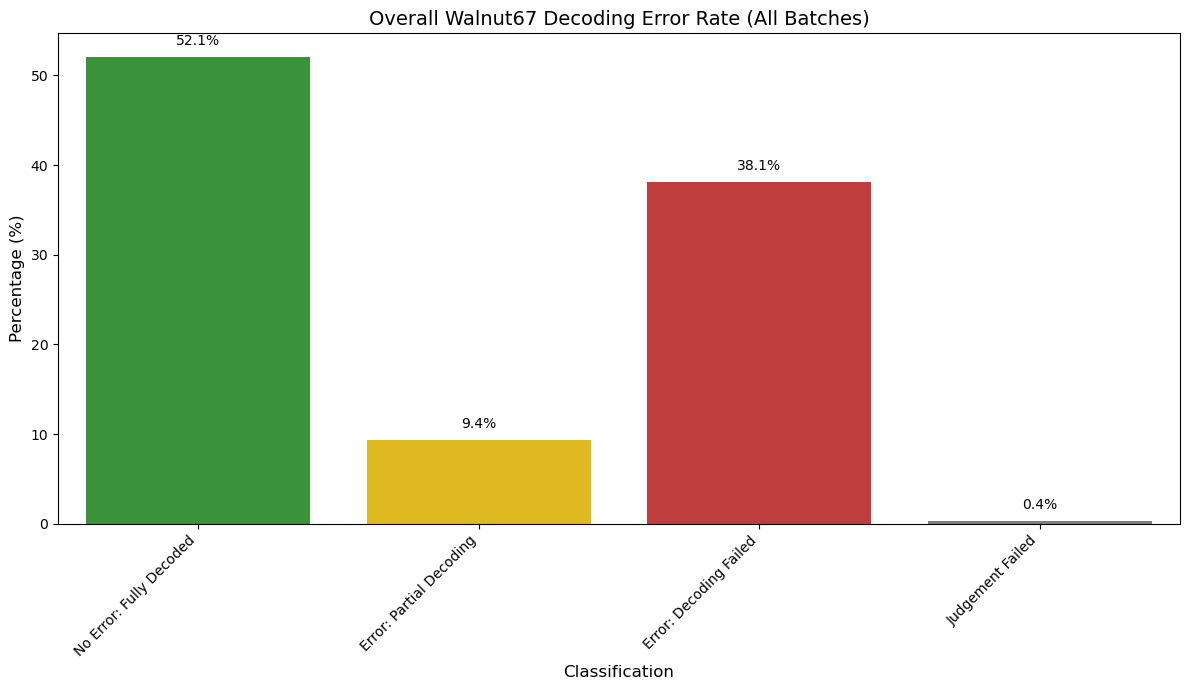

<Figure size 1400x800 with 0 Axes>

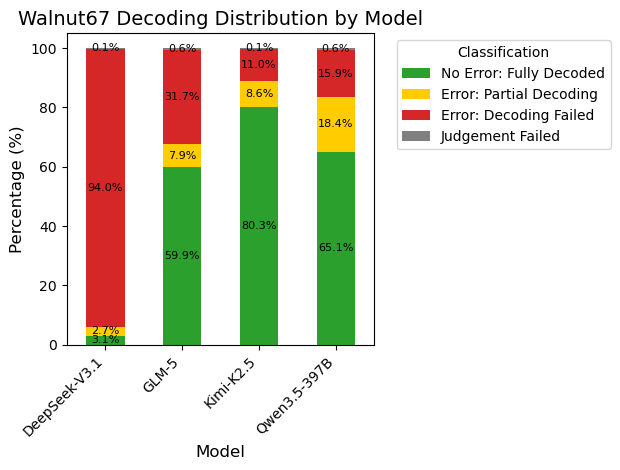


All results (tables + plots) saved to directory: decoding_judgement_results
Files created:
 - overall_aggregate.csv
 - overall_distribution.png
 - per_batch_metrics.csv
 - per_model_distribution.png
 - per_model_metrics.csv


In [8]:
import json
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Create output directory
output_dir = Path("decoding_judgement_results")
output_dir.mkdir(exist_ok=True)

# Define files and batch labels; change if needed
files = {
    "Batch A": "judge_batch_decoding_output_A.jsonl",
    "Batch B": "judge_batch_decoding_output_B.jsonl",
    "Batch C": "judge_batch_decoding_output_C.jsonl"
}

# Violation Categories
categories = [
    "No Error: Fully Decoded",
    "Error: Partial Decoding",
    "Error: Decoding Failed",
    "Judgement Failed"
]

# Standard colour mapping (green/yellow/red/grey)
color_map = {
    "No Error: Fully Decoded": "#2ca02c",   # Green
    "Error: Partial Decoding": "#ffcc00",   # Yellow
    "Error: Decoding Failed": "#d62728",    # Red
    "Judgement Failed": "#7f7f7f"           # Grey
}

def extract_model(custom_id: str) -> str:
    custom_id_lower = custom_id.lower()
    if "deepseek-v3.1" in custom_id_lower or "deepseek" in custom_id_lower:
        return "DeepSeek-V3.1"
    elif "qwen3.5" in custom_id_lower or "qwen" in custom_id_lower:
        return "Qwen3.5-397B"
    elif "kimi-k2.5" in custom_id_lower or "kimi" in custom_id_lower:
        return "Kimi-K2.5"
    elif "glm5" in custom_id_lower or "glm" in custom_id_lower:
        return "GLM-5"
    else:
        return "Unknown"

# Data collection
all_data = []
per_batch_metrics = {}
per_model_metrics = defaultdict(lambda: Counter())

for batch_name, file_path in files.items():
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found. Skipping.")
        continue
   
    batch_counts = Counter()
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
                response_body = entry.get("response", {}).get("body", {})
                choices = response_body.get("choices", [{}])
                if not choices:
                    judgement = "Judgement Failed"
                else:
                    content = choices[0].get("message", {}).get("content", "").strip()
                    if content in categories[:3]:
                        judgement = content
                    else:
                        judgement = "Judgement Failed"
               
                custom_id = entry.get("custom_id", "")
                model = extract_model(custom_id)
               
                all_data.append({
                    "Batch": batch_name,
                    "Model": model,
                    "Judgement": judgement,
                    "Line": line_num
                })
               
                batch_counts[judgement] += 1
                if model != "Unknown":
                    per_model_metrics[model][judgement] += 1
               
            except Exception as e:
                print(f"Error parsing line {line_num} in {batch_name}: {e}")
                all_data.append({
                    "Batch": batch_name,
                    "Model": "Parse Error",
                    "Judgement": "Judgement Failed",
                    "Line": line_num
                })
                batch_counts["Judgement Failed"] += 1
   
    total = sum(batch_counts.values())
    per_batch_metrics[batch_name] = {cat: batch_counts[cat] for cat in categories}
    per_batch_metrics[batch_name]["Total"] = total
    if total > 0:
        for cat in categories:
            per_batch_metrics[batch_name][f"{cat} %"] = round((batch_counts[cat] / total) * 100, 2)

df_all = pd.DataFrame(all_data)

# Overall aggregate
overall_counts = df_all["Judgement"].value_counts().reindex(categories, fill_value=0)
overall_total = len(df_all)
overall_percent = (overall_counts / overall_total * 100).round(2) if overall_total > 0 else pd.Series(0, index=categories)

overall_df = pd.DataFrame({
    "Category": categories,
    "Count": overall_counts.values,
    "Percentage": overall_percent.values
})

# Per model and per batch summaries
model_summary = []
for model, counts in per_model_metrics.items():
    total = sum(counts.values())
    row = {"Model": model, "Total": total}
    for cat in categories:
        row[cat] = counts[cat]
        row[f"{cat} %"] = round((counts[cat] / total * 100), 2) if total > 0 else 0
    model_summary.append(row)

df_models = pd.DataFrame(model_summary)
df_batches = pd.DataFrame.from_dict(per_batch_metrics, orient="index")

# Save tables
df_batches.to_csv(output_dir / "per_batch_metrics.csv")
df_models.to_csv(output_dir / "per_model_metrics.csv")
overall_df.to_csv(output_dir / "overall_aggregate.csv", index=False)

print("Tables saved to", output_dir)

# === Visualization 1: Overall Bar Chart with Colours ===
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=overall_df,
    x="Category",
    y="Percentage",
    hue="Category",
    palette=color_map,
    legend=False,
    order=categories
)

plt.title("Overall Walnut67 Decoding Error Rate (All Batches)", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xlabel("Classification", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Add % labels on bars
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1,
            f'{height:.1f}%',
            ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(output_dir / "overall_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# === Visualization 2: Per-model Stacked Bar Chart with Colours ===
if not df_models.empty:
    plot_df = df_models.set_index("Model")[categories]
    plot_df_percent = plot_df.div(plot_df.sum(axis=1), axis=0) * 100
   
    plt.figure(figsize=(14, 8))
    ax2 = plot_df_percent.plot(
        kind="bar", 
        stacked=True, 
        color=[color_map[cat] for cat in categories]
    )
    
    plt.title("Walnut67 Decoding Distribution by Model", fontsize=14)
    plt.ylabel("Percentage (%)", fontsize=12)
    plt.xlabel("Model", fontsize=12)
    plt.legend(title="Classification", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45, ha='right', fontsize=10)
    
    # Add % labels inside bars
    for c in ax2.containers:
        ax2.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=8)
   
    plt.tight_layout()
    plt.savefig(output_dir / "per_model_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

print(f"\nAll results (tables + plots) saved to directory: {output_dir}")
print("Files created:")
for f in sorted(output_dir.iterdir()):
    print(" -", f.name)